In [14]:
!kaggle datasets download -d jsonali2003/stellar-classification-dataset


Dataset URL: https://www.kaggle.com/datasets/jsonali2003/stellar-classification-dataset
License(s): apache-2.0




  0%|          | 0.00/5.00M [00:00<?, ?B/s]
 20%|██        | 1.00M/5.00M [00:01<00:06, 611kB/s]
 40%|████      | 2.00M/5.00M [00:01<00:02, 1.22MB/s]
 60%|██████    | 3.00M/5.00M [00:02<00:01, 1.97MB/s]
 80%|████████  | 4.00M/5.00M [00:02<00:00, 2.90MB/s]
100%|██████████| 5.00M/5.00M [00:02<00:00, 2.28MB/s]


In [21]:
import zipfile
with zipfile.ZipFile(r'C:\IDE\2 семестр\Классическое МО\stellar-classification-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall(r'C:\IDE\2 семестр\Классическое МО\data')

In [ ]:
'''Теперь скачаем датасет с Kaggle сразу в Google Colab:'''

import opendatasets as od
import pandas

od.download("https://www.kaggle.com/datasets/jsonali2003/stellar-classification-dataset")

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\IDE\2 семестр\Классическое МО\data\StarClassificationDataset.csv")
df.head()

C:\Users\troyd\AppData\Local\Temp\ipykernel_7708\4203420664.py:3: DtypeWarning: Columns (1,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\IDE\2 семестр\Классическое МО\data\StarClassificationDataset.csv")


,object_ID,alpha,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID,class
0,1.240000e+18,135.6891066,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.540000e+18,0.634794,5812,56354,171,GALAXY
1,1.240000e+18,144.8261006,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.180000e+19,0.779136,10445,58158,427,GALAXY
2,1.240000e+18,142.1887896,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.150000e+18,0.644195,4576,55592,299,GALAXY
3,1.240000e+18,338.7410378,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030000e+19,0.932346,9149,58039,775,GALAXY
4,1.240000e+18,345.2825932,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,NaN,301,3,137,6.890000e+18,0.116123,6121,56187,842,GALAXY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   object_ID       100000 non-null  float64
 1   alpha           99999 non-null   object 
 2   delta           99998 non-null   float64
 3   UV_filter       100000 non-null  float64
 4   green_filter    100000 non-null  float64
 5   red_filter      100000 non-null  float64
 6   near_IR_filter  100000 non-null  float64
 7   IR_filter       100000 non-null  float64
 8   run_ID          99994 non-null   object 
 9   rerun_ID        100000 non-null  int64  
 10  cam_col         100000 non-null  int64  
 11  field_ID        100000 non-null  int64  
 12  spec_obj_ID     100000 non-null  float64
 13  red_shift       100000 non-null  float64
 14  plate_ID        100000 non-null  int64  
 15  MJD             100000 non-null  int64  
 16  fiber_ID        100000 non-null  int64  
 17  class      

C:\Users\troyd\AppData\Local\Temp\ipykernel_7708\1600571636.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x ='class', data = df, palette='hls')


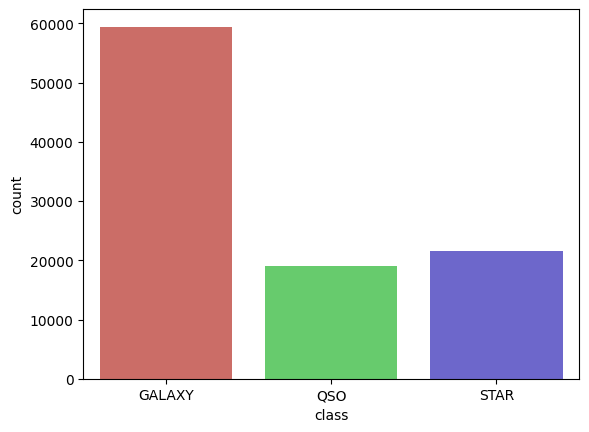

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x ='class', data = df, palette='hls')
plt.show()

In [6]:
'''Выполним минимальную обработку для решения задачи:

Оставим только числовые переменные.
Удалим все объекты (строки), содержащие пропуски.
Удалим не информативные колонки.
Закодируем целевую переменную.
Выделим вектор признаков и целевой переменной.'''
# Удалим все объекты где есть пропуски
df.dropna(inplace=True)
# Удалим неинформативную колонку
df.drop(columns=['object_ID'], inplace=True)

# Возьмем только числовые колонки
numeric_cols = df.select_dtypes(include='number').columns
df_X = df[numeric_cols]

In [7]:
'''Обработаем целевую переменную:'''

from sklearn.preprocessing import LabelEncoder

# Закодируем целевую переменную
# Создание и применение LabelEncoder
encoder = LabelEncoder()
df['class'] = encoder.fit_transform(df['class'])

# Создание словаря соответствия
label_mapping = {class_name: index for index, class_name in enumerate(encoder.classes_)}

print(label_mapping)

{'GALAXY': 0, 'QSO': 1, 'STAR': 2}


In [8]:
'''Выделим вектор признаков и целевой переменной и разделим датасет на подвыборки для обучения и тестирования:
'''
from sklearn.model_selection import train_test_split

X = df_X.copy()
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

print(f'Train shape: {X_train.shape}, {y_train.shape}')
print(f'Test shape: {X_test.shape}, {y_test.shape}')

Train shape: (66660, 14), (66660,)
Test shape: (33331, 14), (33331,)


Обучение алгоритма

In [9]:
sklearn.neighbors.KNeighborsClassifier(
    n_neighbors=5,
    *, 
    weights='uniform', 
    algorithm='auto', 
    leaf_size=30, 
    p=2, 
    metric='minkowski', 
    metric_params=None, 
    n_jobs=None
    )

SyntaxError: Invalid star expression (527770049.py, line 3)

n_neighbors — количество соседей.
weights — функция для весов:
uniform — однородные веса. Все точки в каждой окрестности имеют одинаковый вес.
distance — точки веса обратно пропорциональны их расстоянию. В этом случае более близкие соседи точки запроса будут иметь большее влияние, чем соседи, которые находятся дальше.
algorithm — алгоритм, используемый для вычисления ближайших соседей.
metric — метод расчета расстояния (Евклидово, Манхэттенское и пр.)

In [10]:
from sklearn.neighbors import KNeighborsClassifier # классификатор
from sklearn.neighbors import KNeighborsRegressor # регрессор

from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score

# Список для хранения всех вариантов модели
# и метрик для каждой из них
scores = []

# переберем соседей от 3 до 16 включительно
for i in range(3, 17):
    # словарь для сохренение метрик для одной модели
    score = {}
    # создаем модель с количеством соседей i
    knn = KNeighborsClassifier(i)
    # обучаем модель
    knn.fit(X_train,y_train)
    # метод predict возвращает вектор ответов для X_test
    answers = knn.predict(X_test) 

    # Оцениваем KNN  с кол-вом сосдей i и сохраняем
    score['k'] = i
    score['accuracy'] = accuracy_score(answers,y_test)
    scores.append(score)

# вывод всех вариантов и их метрик
scores = pd.DataFrame(scores)
scores

,k,accuracy
0,3,0.689268
1,4,0.698089
2,5,0.699919
3,6,0.703279
4,7,0.703549
5,8,0.704779
6,9,0.704989
7,10,0.705949
8,11,0.707450
9,12,0.707119


In [11]:
knn = KNeighborsClassifier(15)

# обучаем
knn.fit(X_train,y_train)

# предсказываем значения
y_pred = knn.predict(X_test)

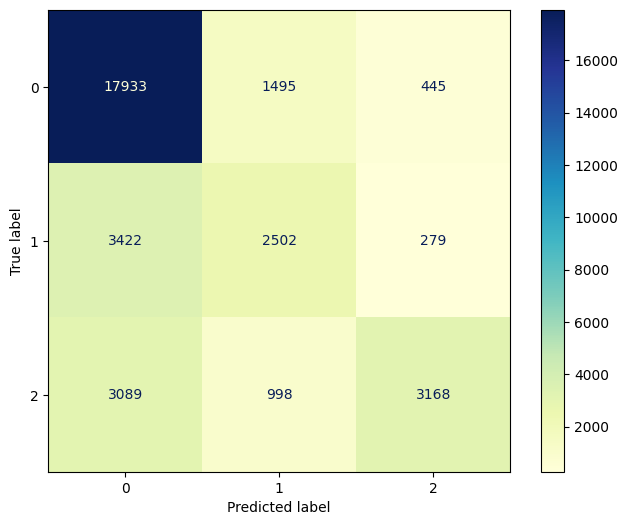

In [12]:
'''Рассмотрим пример с конкретными числами на ситуации из предыдущего урока:
    Теперь посмотрим на Confusion matrix результатов:
'''
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8,6), dpi=100)

display = ConfusionMatrixDisplay(conf_matrix, display_labels=knn.classes_)

display.plot(ax=ax, cmap='YlGnBu')

В этой матрице строки — это фактические классы, а столбцы — предсказанные классы:

Первая строка (GALAXY): 17933 объектов предсказаны верно (TP), но 1495 ошибочно классифицированы как STAR, а 445 — как QSO.
Вторая строка (STAR): 2502 объектов предсказаны верно, но 3422 приняты за GALAXY, а 279 — за QSO.
Третья строка (QSO): 3168 объектов предсказаны верно, но 3089 приняты за GALAXY, а 998 — за STAR.
Таким образом, для класса GALAXY общее число ошибок будет равно 1495 + 445. Аналогично для других классов.

Почему стандартные Accuracy, Precision, Recall и F1 могут быть проблемными
В многоклассовой классификации метрики из sklearn.metrics могут давать некорректные оценки. Причин — несколько.

Несбалансированные классы.
Если один класс встречается намного чаще других, он доминирует в метриках, что маскирует ошибки по редким классам.
Несимметричные ошибки.
Ошибка A → B (правильный ответ А, а предсказали В) может быть менее критична, чем A → C, но стандартные метрики этого не учитывают.
Разные способы усреднения.
Macro — precision и recall рассчитываются для каждого класса отдельно, а затем усредняются. Подходит для равномерной оценки всех классов, но игнорирует их частоту.
Weighted — также рассчитывается per-class, но с учетом доли объектов каждого класса в выборке. Хорош для несбалансированных данных.
Micro — суммирует TP, FP и FN по всем классам и затем считает precision/recall. Подходит для задач, где важна общая точность.
В многоклассовой классификации метрики Precision, Recall, Accuracy и F1-score рассчитываются либо для каждого класса отдельно, либо усредняются разными способами (macro, micro, weighted).

Precision (точность)

Precision измеряет, насколько точно предсказания модели соответствуют фактическому классу.
В общем случае для многоклассовой классификации метрика рассчитывается так:

$Precision_i​= \frac{TP_i}{TP_i​+FP_i​}$,

где:

 (True Positives) — количество объектов, правильно предсказанных как класс ,
 (False Positives) — количество объектов, ошибочно предсказанных как класс , но относящихся к другому классу.
Усреднение:

Macro Precision.
Micro Precision.
Weighted Precision.

Посмотрим на примере, как считается Precision. Для начала рассчитывается Precision для каждого класса отдельно (числа в примере отличаются от чисел в матрице выше):

Precision (GALAXY):

$\frac{17927}{17927+3422+3087} = \frac{17927}{24436}​≈0.734$

Интерпретация: из всех объектов, которые модель предсказала как GALAXY (24 436 объектов), 73,4% действительно галактики, а 26,6% — это звезды или квазары, ошибочно принятые за галактики.
Ошибка: модель часто путает звезды и квазары с галактиками (3,422 и 3,087 ошибок соответственно).
Precision (STAR):

$\frac{2502}{2502+1498+1000} = \frac{2502}{5000}≈0.500$

Интерпретация: из всех объектов, которые модель предсказала как STAR (5000 объектов), только 50% действительно звезды, а 50% — это другие объекты (ошибки).
Ошибка: почти половина предсказанных звезд (1498 + 1000 = 2498 объектов) на самом деле являются галактиками или квазарами.
Этот класс имеет самый низкий Precision, значит, модель плохо отличает звезды от других объектов.
Precision (QSO):

$\frac{3168}{3168 + 448 + 279} = \frac{3168}{3895} ​≈0.813$

Интерпретация: из всех объектов, которые модель предсказала как QSO (3895 объектов), 81,3% — действительно квазары, а 18,7% ошибочно оказались галактиками или звездами.
Ошибка: модель реже путает другие объекты с квазарами (448 и 279 ошибок).
Этот класс имеет самый высокий Precision, значит, если модель предсказывает QSO, это, скорее всего, действительно квазар.
Итоговый Precision можно подсчитать двумя способами:

Macro Precision (средний Precision по всем классам):

$Precision_{macro}=\frac{Precision_{GALAXY} + Precision_{STAR}+Precision_{QSO3}}{3}$

$Precision_{macro} = \frac{0.734 + 0.500 + 0.813}{3} = \frac{2.047}{3}​≈0.682$

Weighted Precision (Precision, взвешенный по количеству объектов каждого класса):

$Precision_{weighted}=\frac{Precision_{GALAXY}+Precision_{STAR}+Precision_{QSO3}}{w1+w2+w3}$,

где  — количество объектов каждого класса.

$Precision_{weighted} = \frac{59445 \cdot 0.734 + 21594 \cdot 0.500 + 18961 \cdot 0.813}{59445 + 21594 + 18961}≈0.698$

Метрики Recall, F1-score рассчитываются по аналогичным образом.

In [13]:
'''Теперь посмотрим, как можно рассчитать метрики с использование Python и Sklearn:'''

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# 2. Precision (по классам и усредненный)
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_micro = precision_score(y_test, y_pred, average='micro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')

print(f"Precision Macro: {precision_macro:.4f}")
print(f"Precision Micro: {precision_micro:.4f}")
print(f"Precision Weighted: {precision_weighted:.4f}")

# 3. Recall (по классам и усредненный)
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_micro = recall_score(y_test, y_pred, average='micro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')

print(f"Recall Macro: {recall_macro:.4f}")
print(f"Recall Micro: {recall_micro:.4f}")
print(f"Recall Weighted: {recall_weighted:.4f}")

# 4. F1-score (по классам и усредненный)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

# 5. Матрица ошибок (Confusion Matrix)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# 6. Подробный отчет по классам
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7081
Precision Macro: 0.6828
Precision Micro: 0.7081
Precision Weighted: 0.7078
Recall Macro: 0.5808
Recall Micro: 0.7081
Recall Weighted: 0.7081
F1 Macro: 0.6082
F1 Micro: 0.7081
F1 Weighted: 0.6894
Confusion Matrix:
[[17933  1495   445]
 [ 3422  2502   279]
 [ 3089   998  3168]]
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.90      0.81     19873
           1       0.50      0.40      0.45      6203
           2       0.81      0.44      0.57      7255

    accuracy                           0.71     33331
   macro avg       0.68      0.58      0.61     33331
weighted avg       0.71      0.71      0.69     33331



Что важно помнить о метриках в многоклассовой классификации
Accuracy может быть обманчивой.
В случае дисбаланса классов (например, GALAXY = 52%, STAR = 19%, QSO = 17%) accuracy может быть высокой, даже если модель плохо работает для малых классов.
Precision и Recall нужно анализировать отдельно для каждого класса.
Высокий Precision означает, что предсказания этого класса надежны. Высокий Recall означает, что модель редко пропускает объекты этого класса. STAR имеет низкий Recall (40%) и Precision (50%) → его модель плохо различает.
F1-score показывает баланс Precision и Recall.
Для GALAXY F1=0.81F1 = 0.81F1=0.81 → модель хорошо справляется. Для STAR F1=0.45F1 = 0.45F1=0.45 → модель путает звезды с другими объектами.
Confusion Matrix помогает понять, какие классы путаются.
STAR → часто принимаются за GALAXY. QSO → часто принимаются за GALAXY. Это говорит о том, что модель может быть улучшена за счет балансировки классов или добавления новых признаков.
Из этого урока вам важно запомнить, что:

Обычные precision/recall не всегда корректны для многоклассовых задач.
Важно анализировать матрицу ошибок и использовать усреднение метрик (macro, weighted, micro) в зависимости от задачи.
Визуализация и анализ ошибок помогают находить слабые места модели и улучшать ее работу.

 Балансировка классов

 Особенно чувствительны к дисбалансу алгоритмы, основанные на метриках расстояния, такие как K-ближайших соседей (KNN). Если в обучающей выборке один из классов встречается намного реже, у нового объекта среди k ближайших соседей этот класс будет представлен с меньшей вероятностью, что приведет к его заниженной классификации.

Поэтому перед обучением модели важно применять методы балансировки классов, которые можно разделить на две основные группы:

Undersampling (уменьшение числа объектов мажоритарного (бОльшего) класса).
Oversampling (увеличение числа объектов миноритарного (меньшего) класса).
Рассмотрим каждый из них отдельно.

Undersampling (уменьшение числа объектов мажоритарного класса)
В данном подходе количество примеров мажоритарного класса искусственно сокращается за счет удаления части объектов. Это можно сделать случайным образом или с помощью специальных алгоритмов:

NearMiss — метод, который оставляет только те объекты мажоритарного класса, которые находятся ближе всего к миноритарным.
Tomek Links — метод, удаляющий примеры, которые имеют ближайшего соседа из другого класса, помогают сделать границы между классами более четкими.
Edited Nearest Neighbors (ENN) — удаляет объекты мажоритарного класса, если они не согласуются с ближайшими соседями.
Пример кода с использованием библиотеки imbalanced-learn:

In [14]:
from imblearn.under_sampling import NearMiss, RandomUnderSampler

# Создание объекта для undersampling
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

ModuleNotFoundError: No module named 'imblearn'